### **Task 1.2 | Implement a Python function to evaluate the marginalized log joint distribution**


We arrived at:
\begin{align}
    p(y, \theta) & = \left[ \prod^N_{n=1}(\mathcal{N}(y_n | w^T_1, x_n, \sigma^2_1) \sigma(v^Tx_n) + \mathcal{N}(y_n|w^T_0, x_n, \sigma^2_0)(1-\sigma{v^Tx_n})) \right] \\ & \mathcal{N}(\boldsymbol{w}_0 | \boldsymbol{0}, \tau^2 \boldsymbol{I})
 \mathcal{N}(\boldsymbol{w}_1 | \boldsymbol{0}, \tau^2 \boldsymbol{I})  \mathcal{N}(\boldsymbol{v} | \boldsymbol{0}, \tau^2 \boldsymbol{I}) \mathcal{N}_+(\tau^2 | 0, 1) \mathcal{N}_+(\sigma_0 | 0, 1) \mathcal{N}_+(\sigma_1 | 0, 1)
\end{align}
Which we have to implement in Python, and we start by first defining the sigmoid.

In [1]:
%matplotlib inline
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as snb
from scipy.optimize import minimize
from scipy.stats import norm
import jax
import numpy as np

# use 64-bit precision
from jax import config
config.update("jax_enable_x64", True)

snb.set_style('darkgrid')
snb.set_theme(font_scale=1.1)

SOME NOTES for how we implemented everthing, so first off we know that the gaussian is:
$$
\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$
We have:
$$
\tau, \sigma_0^2 \sigma_1^2 \sim \mathcal{N}_+(0, 1)
$$
And then we have:
$$
w_0, w_1, v \sim \mathcal{N}(\boldsymbol{0}, \tau^2 \boldsymbol{I})
$$
So the first gaussian looks like:
$$
\mathcal{N}_+(0, 1) =\frac{1}{\sqrt{2 \pi}} \exp\left( -\frac{x^2}{2}\right) \text{ for } x > 0
$$
Next:
$$
 \mathcal{N}(\boldsymbol{0}, \tau^2 \boldsymbol{I}) = \frac{1}{(2\pi \tau^2)^{D/2}} \exp\left( -\frac{1}{2\tau^2} \boldsymbol{x}^T \boldsymbol{x} \right)
$$

In [2]:
def log_joint(w0, w1, v, tau, sigma0_sq, sigma1_sq, x, y):
    log_prior_tau = jax.scipy.stats.norm.logpdf(tau, loc=0, scale=1)
    log_prior_sigma0 = jax.scipy.stats.norm.logpdf(sigma0_sq, loc=0, scale=1)
    log_prior_sigma1 = jax.scipy.stats.norm.logpdf(sigma1_sq, loc=0, scale=1)

    # because they are vectors
    log_prior_w0 = jax.scipy.stats.norm.logpdf(w0, loc=0, scale=tau).sum()
    log_prior_w1 = jax.scipy.stats.norm.logpdf(w1, loc=0, scale=tau).sum()
    log_prior_v = jax.scipy.stats.norm.logpdf(v, loc=0, scale=tau).sum()

    # now for the likelihood
    gate_logit = jnp.dot(x, v) # prob for z_n = 1
    log_pi = jax.nn.log_sigmoid(gate_logit) 
    log_1_minus_pi = jax.nn.log_sigmoid(-gate_logit)

    log_1 = jax.scipy.stats.norm.logpdf(y, loc=jnp.dot(x, w1), scale=jnp.sqrt(sigma1_sq))
    log_0 = jax.scipy.stats.norm.logpdf(y, loc=jnp.dot(x, w0), scale=jnp.sqrt(sigma0_sq))

    # combine
    joint_1 = log_pi + log_1
    joint_0 = log_1_minus_pi + log_0
    combined_log_lik = jax.scipy.special.logsumexp(jnp.stack([joint_1, joint_0]), axis=0)
    log_lik = jnp.sum(combined_log_lik)
    return log_prior_tau + log_prior_sigma0 + log_prior_sigma1 + log_prior_w0 + log_prior_w1 + log_prior_v + log_lik

### **Task 1.3 | Run a Metropolis-Hasting sampler to infer all parameters. Explain the settings you used (number of iterations, proposal distribution etc).**


We use the code from week 8 notebook.

In [3]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        ##############################################
        # Your solution goes here
        ##############################################
        

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
        
        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))
        
        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)


        
        ##############################################
        # End of solution
        ##############################################
            
        thetas.append(theta_next)
        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas

First we have to load X and Y from data.

In [4]:
data_path = "data_assignment3.npz"
df = np.load(data_path)
X_raw = jnp.array(df['x'])                                    # shape (N,)
X = jnp.column_stack([X_raw, jnp.ones(len(X_raw))])           # shape (N, 2)
y = jnp.array(df['t'])                                        # shape (N,)

print("Data shapes: X: {}, y: {}".format(X.shape, y.shape))

Data shapes: X: (200, 2), y: (200,)


In [5]:
num_params = 6

def log_target(theta):
    w0       = theta[0:2]
    w1       = theta[2:4]
    v        = theta[4:6]
    tau      = theta[6]
    s0_sq    = theta[7]
    s1_sq    = theta[8]
    if tau <= 0 or s0_sq <= 0 or s1_sq <= 0:
        return -jnp.inf
    return log_joint(w0, w1, v, tau, s0_sq, s1_sq, X, y)

theta_init = jnp.array([0.0, 0.0, 0.0, 1.0, 1.0, 1.0])

tau_proposal = 0.4
num_iterations = 10000
warm_up = 2000

thetas = metropolis(log_target, num_params, tau_proposal, num_iterations,
                    theta_init=theta_init, seed=0)
post_samples = thetas[warm_up:]

Acceptance ratio: 0.03


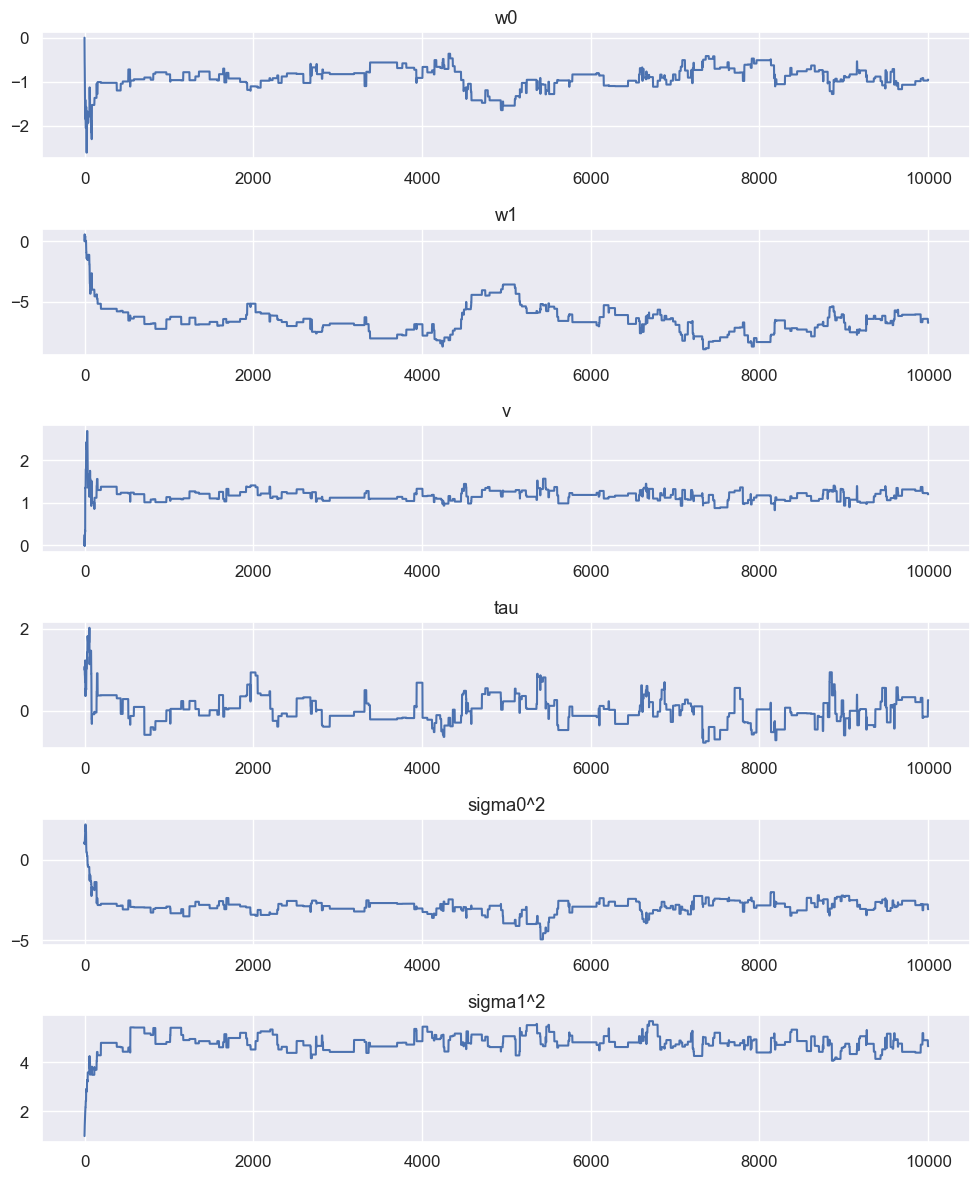

In [6]:
# plot the thetas
param_names = ['w0', 'w1', 'v', 'tau', 'sigma0^2', 'sigma1^2']
fig, axes = plt.subplots(num_params, 1, figsize=(10, 2*num_params))
for i in range(num_params):
    axes[i].plot(thetas[:, i])
    axes[i].set_title(param_names[i])
plt.tight_layout()
plt.show()

### **Task 1.4 | Report the posterior mean and 95 \% credibility intervals for all parameters.**

In [7]:
# We discard warm-up samples
post_samples = thetas[warm_up:] 

# parameter names
param_names = ['w0', 'w1', 'v', 'tau', 'sigma0_sq', 'sigma1_sq']

print(f"{'Parameter':<12} | {'Mean':<10} | {'95% Credibility Interval':<25}")
print("-" * 55)

# calculate statistics
for i, name in enumerate(param_names):
    samples = post_samples[:, i]
    
    p_mean = jnp.mean(samples)
    
    lower = jnp.percentile(samples, 2.5)
    upper = jnp.percentile(samples, 97.5)
    
    print(f"{name:<12} | {p_mean:<10.4f} | [{lower:>8.4f}, {upper:>8.4f}]")

Parameter    | Mean       | 95% Credibility Interval 
-------------------------------------------------------
w0           | -0.8932    | [ -1.4826,  -0.5007]
w1           | -6.6747    | [ -8.3152,  -4.0404]
v            | 1.1658     | [  0.9374,   1.3750]
tau          | -0.0034    | [ -0.5730,   0.6859]
sigma0_sq    | -2.9385    | [ -3.9934,  -2.2565]
sigma1_sq    | 4.7800     | [  4.2498,   5.5000]


### **Task 1.5 | For $x \in [−12, 12]$, plot posterior predictive distribution for $p(\pi^*|y, x^*)$, $p(y^*|y, x^*, z^* = 0)$ and $p(y^* |y, x,z^* = 1)$ on top of the data.**

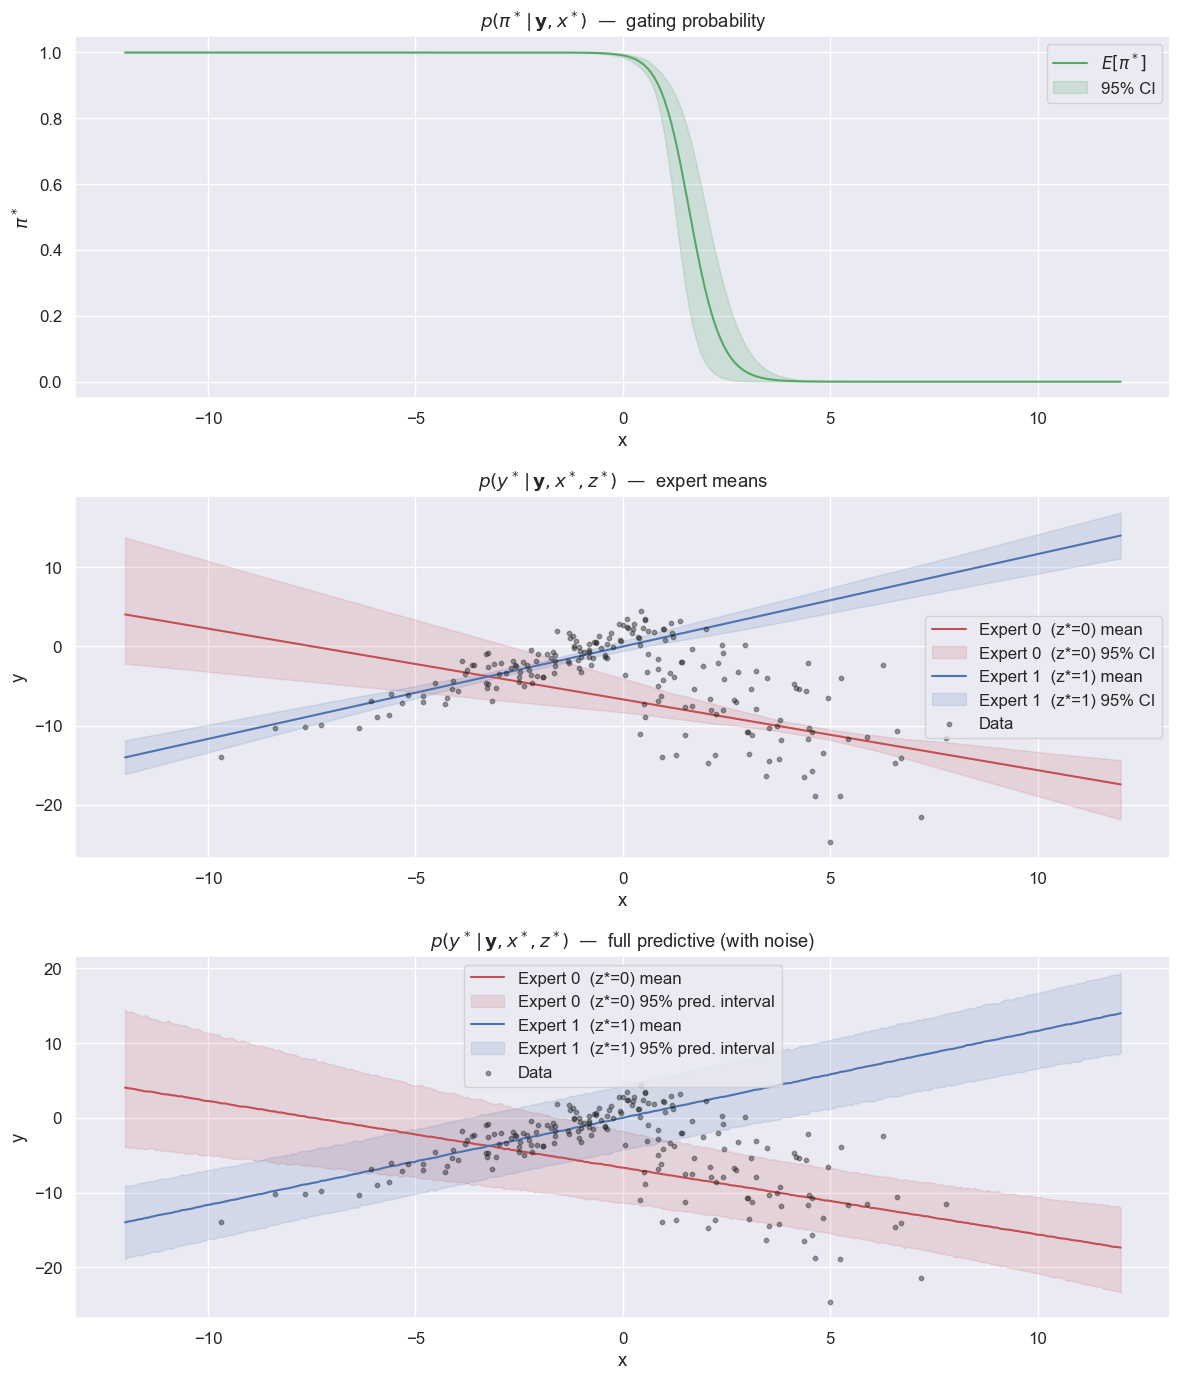

In [8]:
x_star_raw = jnp.linspace(-12, 12, 300)
x_star = jnp.column_stack([x_star_raw, jnp.ones(300)])   # (300, 2) with bias

sigmoid = lambda z: 1.0 / (1.0 + jnp.exp(-z))

pi_samples  = []   # p(pi* | y, x*)           shape per sample: (300,)
mu0_samples = []   # mean of expert 0          (300,)
mu1_samples = []   # mean of expert 1          (300,)
y0_samples  = []   # full predictive draws z*=0
y1_samples  = []   # full predictive draws z*=1

key = random.PRNGKey(42)
for i in range(len(post_samples)):
    theta   = post_samples[i]
    w0, w1, v = theta[0:2], theta[2:4], theta[4:6]
    s0_sq, s1_sq = theta[7], theta[8]

    pi  = sigmoid(x_star @ v)           # (300,)
    mu0 = x_star @ w0                   # (300,)
    mu1 = x_star @ w1                   # (300,)

    pi_samples.append(pi)
    mu0_samples.append(mu0)
    mu1_samples.append(mu1)

    # draw one y* sample per x* for the full predictive (noise included)
    key, k0, k1 = random.split(key, 3)
    y0_samples.append(mu0 + jnp.sqrt(s0_sq) * random.normal(k0, shape=(300,)))
    y1_samples.append(mu1 + jnp.sqrt(s1_sq) * random.normal(k1, shape=(300,)))

pi_samples  = jnp.array(pi_samples)   # (S, 300)
mu0_samples = jnp.array(mu0_samples)
mu1_samples = jnp.array(mu1_samples)
y0_samples  = jnp.array(y0_samples)
y1_samples  = jnp.array(y1_samples)

# PLOTTING
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
xs = x_star_raw

# Panel 1: gating probability p(pi* | y, x*)
pi_mean  = jnp.mean(pi_samples, axis=0)
pi_lower = jnp.percentile(pi_samples, 2.5,  axis=0)
pi_upper = jnp.percentile(pi_samples, 97.5, axis=0)

axes[0].plot(xs, pi_mean, 'g-', label=r'$E[\pi^*]$')
axes[0].fill_between(xs, pi_lower, pi_upper, color='g', alpha=0.2, label='95% CI')
axes[0].set(title=r'$p(\pi^*\,|\,\mathbf{y}, x^*)$  —  gating probability',
            xlabel='x', ylabel=r'$\pi^*$', ylim=[-0.05, 1.05])
axes[0].legend()

# Panel 2: expert predictive means p(y* | y, x*, z*=0/1)
for mu_s, col, lbl in [(mu0_samples, 'r', 'Expert 0  (z*=0)'),
                        (mu1_samples, 'b', 'Expert 1  (z*=1)')]:
    m     = jnp.mean(mu_s, axis=0)
    lo    = jnp.percentile(mu_s, 2.5,  axis=0)
    hi    = jnp.percentile(mu_s, 97.5, axis=0)
    axes[1].plot(xs, m, color=col, label=f'{lbl} mean')
    axes[1].fill_between(xs, lo, hi, color=col, alpha=0.15, label=f'{lbl} 95% CI')

axes[1].scatter(X_raw, y, s=10, c='k', alpha=0.4, label='Data', zorder=5)
axes[1].set(title=r'$p(y^*\,|\,\mathbf{y}, x^*, z^*)$  —  expert means',
            xlabel='x', ylabel='y')
axes[1].legend()

# Panel 3: full predictive (noise) p(y* | y, x*, z*=0/1)
for y_s, col, lbl in [(y0_samples, 'r', 'Expert 0  (z*=0)'),
                       (y1_samples, 'b', 'Expert 1  (z*=1)')]:
    m  = jnp.mean(y_s, axis=0)
    lo = jnp.percentile(y_s, 2.5,  axis=0)
    hi = jnp.percentile(y_s, 97.5, axis=0)
    axes[2].plot(xs, m, color=col, label=f'{lbl} mean')
    axes[2].fill_between(xs, lo, hi, color=col, alpha=0.15,
                          label=f'{lbl} 95% pred. interval')

axes[2].scatter(X_raw, y, s=10, c='k', alpha=0.4, label='Data', zorder=5)
axes[2].set(title=r'$p(y^*\,|\,\mathbf{y}, x^*, z^*)$  —  full predictive (with noise)',
            xlabel='x', ylabel='y')
axes[2].legend()

plt.tight_layout()
plt.show()

### **Task 1.6 | For $x\in [−12,12]$, plot posterior predictive distribution for $p(y^*|y,x^*)$.**

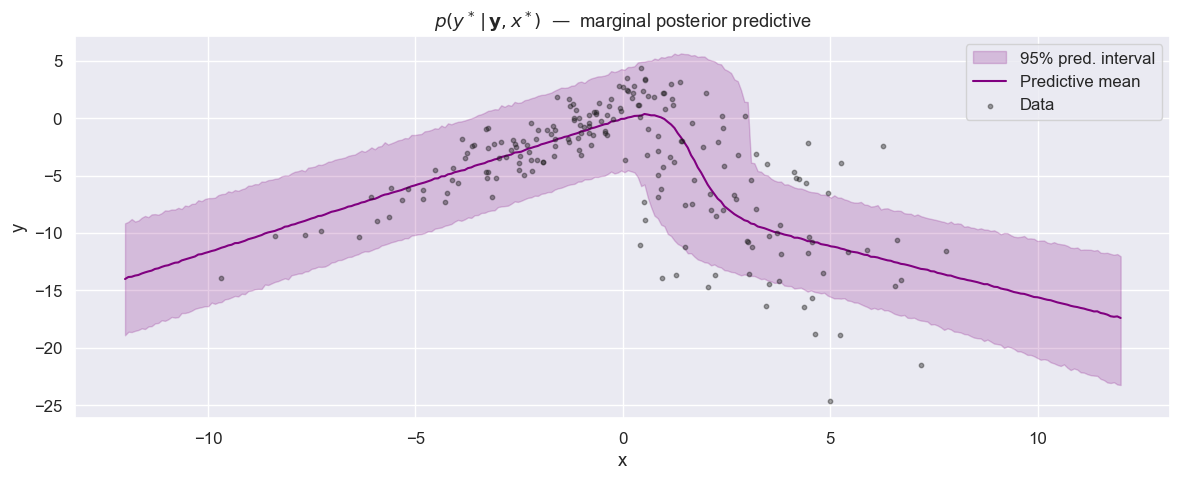

In [9]:
y_marg_samples = []
key = random.PRNGKey(0)
for i in range(len(post_samples)):
    theta = post_samples[i]
    w0, w1, v = theta[0:2], theta[2:4], theta[4:6]
    s0_sq, s1_sq = theta[7], theta[8]

    pi  = sigmoid(x_star @ v)                    # (300,)
    mu0 = x_star @ w0
    mu1 = x_star @ w1

    key, kz, kn = random.split(key, 3)
    z_star = random.bernoulli(kz, pi)            # (300,) bool
    mu_mix = jnp.where(z_star, mu1, mu0)
    s_mix  = jnp.where(z_star, jnp.sqrt(s1_sq), jnp.sqrt(s0_sq))
    y_marg_samples.append(mu_mix + s_mix * random.normal(kn, shape=(300,)))

y_marg_samples = jnp.array(y_marg_samples)      # (S, 300)

fig, ax = plt.subplots(figsize=(12, 5))
m  = jnp.mean(y_marg_samples, axis=0)
lo = jnp.percentile(y_marg_samples, 2.5,  axis=0)
hi = jnp.percentile(y_marg_samples, 97.5, axis=0)

ax.fill_between(xs, lo, hi, color='purple', alpha=0.2, label='95% pred. interval')
ax.plot(xs, m, 'purple', label='Predictive mean')
ax.scatter(X_raw, y, s=10, c='k', alpha=0.4, label='Data', zorder=5)
ax.set(title=r'$p(y^*\,|\,\mathbf{y}, x^*)$  —  marginal posterior predictive',
       xlabel='x', ylabel='y')
ax.legend()
plt.tight_layout()
plt.show()